# **📊 Proyecto TelecomX - Parte 2**
---

<br>

**Challenge**: Segunda parte del desafío Telecom X de Data Science de [Alura Latam](https://www.aluracursos.com/)

**Formación**: Estadisticas y Machine Learning G9 - ONE

**Alumna**: Aiello Mariana

<br>




## 🎯 Objetivo del Proyecto (Parte 2):

Desarrollar y evaluar modelos predictivos de *Machine Learning* capaces de **anticipar la evasión de clientes (churn)** en la empresa TelecomX. Para ello, se utilizarán algoritmos de clasificación supervisada, como **Regresión Logística** y **Random Forest**, con el fin de identificar patrones que permitan detectar clientes con alto riesgo de cancelar el servicio.

El análisis se realizará a partir del dataset limpio y estandarizado obtenido en la **Parte 1** del proyecto de Telecom, donde se aplicaron procesos de tratamiento de valores nulos, estandarización de variables y creación de métricas de negocio.

(con cierto proceso de limpieza y estandarizacion realizado en ...) !!



El proyecto se estructura en cuatro fases principales:

### 1. Preparación de datos
- Encoding de variables
- Normalización
- Balanceo de clases

### 2. División del dataset
Separación de datos de entrenamiento y prueba mediante **train-test split estratificado**.

### 3. Modelado predictivo
Entrenamiento de modelos de clasificación.

### 4. Evaluación y análisis
Comparación de métricas de desempeño para seleccionar el modelo más efectivo y generar conclusiones orientadas a estrategias de retención de clientes.

<br>


## 📌 <font color=green> 1. Preparación de los Datos </font>

Antes de entrenar los modelos predictivos, es necesario transformar el dataset limpio obtenido en la **Parte 1** en un formato adecuado para los algoritmos de Machine Learning.  Los modelos no pueden procesar directamente variables de texto o categorías, por lo que es necesario convertir toda la información en representaciones numéricas.

En esta etapa se realizan diferentes procesos de **preprocesamiento de datos**, incluyendo la selección de variables relevantes, la codificación de variables categóricas, el análisis del balanceo de la variable objetivo y la normalización de variables numéricas.

<br>

El proceso incluye las siguientes tareas:

1. **Extracción del dataset** tratado.
2. **Eliminación de columnas irrelevantes** o que no aportan valor predictivo.
3. **Encoding de variables categóricas** para convertirlas en representaciones numéricas.
4. **Verificación del balanceo de clases** de la variable objetivo (churn).
5. **Escalado de variables numéricas** para mejorar el rendimiento de algunos algoritmos.

<br>

**Dataset de entrada:** `datos_tratados.csv`  
**Dimensiones:** 7.043 registros × 23 variables

### 1.1 Extracción del Dataset Tratado

En esta etapa se importa el archivo `datos_tratados.csv`, generado al final del **Análisis Exploratorio de Datos (EDA)** de la Parte 1 del proyecto de Telecom.

Este dataset contiene la información ya **limpia y estandarizada**, incluyendo transformaciones básicas aplicadas durante el proceso de preparación inicial, como:
- conversión de variables binarias a valores numéricos (0/1)
- estandarización de nombres de columnas y categorías     !!!xxxxx!!!!
- creación de algunas variables derivadas relevantes para el análisis

Además, se importan las librerías necesarias que serán utilizadas durante la fase de **preprocesamiento y modelado**.

In [63]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# librerías para ML y preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE

# dataset con datos tratados de Telecom - parte 1
df = pd.read_csv('datos_tratados.csv')

# mostrar DataFrame
print(f"\nDataset cargado exitosamente")
print(f"   • Registros: {df.shape[0]:,}")
print(f"   • Variables: {df.shape[1]}\n")

print(f"\nIformación general:\n")
print(df.info())

print(f"\nPrimeros registros:\n")
df.head(4)


Dataset cargado exitosamente
   • Registros: 7,043
   • Variables: 23


Iformación general:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         7043 non-null   object 
 1   churn               7043 non-null   int64  
 2   gender              7043 non-null   int64  
 3   senior_citizen      7043 non-null   int64  
 4   partner             7043 non-null   int64  
 5   dependents          7043 non-null   int64  
 6   tenure              7043 non-null   int64  
 7   phone_service       7043 non-null   int64  
 8   multiple_lines      7043 non-null   object 
 9   internet_service    7043 non-null   object 
 10  online_security     7043 non-null   object 
 11  online_backup       7043 non-null   object 
 12  device_protection   7043 non-null   object 
 13  tech_support        7043 non-null   object 
 14  streaming_

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias,cantidad_servicios
0,0002-ORFBO,0,1,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19,3
1,0003-MKNFE,0,0,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00,1
2,0004-TLHLJ,1,0,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,1,0,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27,4


### 1.2 Eliminación de Columnas Irrelevantes

El rendimiento de un modelo predictivo puede verse afectado si se incluyen variables redundantes o sin relación con la variable objetivo (*churn*). A partir de los resultados obtenidos durante el **Análisis Exploratorio(EDA)** (Parte 1) se decide eliminar las siguientes columnas:


* **`customer_id`:** identificador único del sistema sin poder predictivo.

* **`cuentas_diarias`:** variable redundante. Al ser una división matemática directa del cargo mensual (`monthly_charges` / 30), aporta exactamente la misma información.

* **`total_charges`:** presenta multicolinealidad ya que tiene una correlación altísima con la antigüedad (`tenure`). Mantener ambas variables explicaría lo mismo dos veces, confundiendo a los algoritmos.

* **`cantidad_servicios`**: variable creada durante el Análisis Exploratorio de TelecomX Parte 1. Se elimina por presentar multicolinealidad, ya que es una combinación matemática de los servicios individuales (Soporte Técnico, Seguridad Online, etc.), y mantenerla solo duplicaría la información presente en esas columnas

* **`gender`:** el análisis visual demostró que la proporción de abandono es equitativa para hombres y mujeres, por lo que el género no influye en la cancelación.

#### Verificación de Independencia Estadística (Chi-Cuadrado)

Se aplica la **Prueba de Chi-Cuadrado** Para corroborar si existen otras columnas categóricas o binarias que no aportan valor al modelo.

Si el **valor p (p-value)** es mayor a 0.05, se concluye que la variable es independiente y no influye en la decisión de cancelación del cliente. En ese caso, la columna puede ser eliminada.

In [64]:
print("PRUEBA DE CHI-CUADRADO\n")
from scipy.stats import chi2_contingency

# obtener columnas que no entran en la prueba
columnas_excluidas = ['customer_id', 'churn', 'tenure', 'monthly_charges', 'total_charges', 'cuentas_diarias', 'cantidad_servicios']

# filtrar para obtener variables a evaluar
variables_a_evaluar = [col for col in df.columns if col not in columnas_excluidas]

# listas para guardar resultados
variables_utiles = []
variables_a_descartar = []

# bucle para probar todas las variables
for col in variables_a_evaluar:
    tabla_contingencia = pd.crosstab(df[col], df['churn'])
    chi2, p_value, dof, expected = chi2_contingency(tabla_contingencia)

    if p_value > 0.05:
        variables_a_descartar.append(col)
        print(f"x {col}:  p-value = {p_value:.4f} ---> Sin relación (Eliminar)")
    else:
        variables_utiles.append(col)
        print(f"• {col}:  p-value = {p_value:.4f} -> Fuerte relación (Conservar)")

print(f"\nResumen: se sugiere eliminar {len(variables_a_descartar)} variables: {variables_a_descartar}")

PRUEBA DE CHI-CUADRADO

x gender:  p-value = 0.4866 ---> Sin relación (Eliminar)
• senior_citizen:  p-value = 0.0000 -> Fuerte relación (Conservar)
• partner:  p-value = 0.0000 -> Fuerte relación (Conservar)
• dependents:  p-value = 0.0000 -> Fuerte relación (Conservar)
x phone_service:  p-value = 0.3388 ---> Sin relación (Eliminar)
• multiple_lines:  p-value = 0.0035 -> Fuerte relación (Conservar)
• internet_service:  p-value = 0.0000 -> Fuerte relación (Conservar)
• online_security:  p-value = 0.0000 -> Fuerte relación (Conservar)
• online_backup:  p-value = 0.0000 -> Fuerte relación (Conservar)
• device_protection:  p-value = 0.0000 -> Fuerte relación (Conservar)
• tech_support:  p-value = 0.0000 -> Fuerte relación (Conservar)
• streaming_tv:  p-value = 0.0000 -> Fuerte relación (Conservar)
• streaming_movies:  p-value = 0.0000 -> Fuerte relación (Conservar)
• contract:  p-value = 0.0000 -> Fuerte relación (Conservar)
• paperless_billing:  p-value = 0.0000 -> Fuerte relación (Conser

**Resultados de la prueba de Chi-Cuadrado**

Los resultados indican que las variables **`gender`** y **`phone_service`**
no tienne un impacto significativo en el comportamiento de evasión de los clientes, por lo que pueden ser eliminadas del dataset.


In [65]:
print('Eliminación de columnas irrelevantes\n')

# columnas a eliminar
columnas_a_eliminar = ['customer_id', 'total_charges', 'cuentas_diarias', 'gender', 'phone_service', 'cantidad_servicios']
print(f"• Columnas a eliminar: {columnas_a_eliminar}\n")

# eliminación de columnas
df= df.drop(columns=columnas_a_eliminar)
print(f"• Columnas restantes: {df.columns}\n")
print(f"Nuevas dimensiones: {df.shape}")


Eliminación de columnas irrelevantes

• Columnas a eliminar: ['customer_id', 'total_charges', 'cuentas_diarias', 'gender', 'phone_service', 'cantidad_servicios']

• Columnas restantes: Index(['churn', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges'],
      dtype='object')

Nuevas dimensiones: (7043, 17)


### 1.3 Encoding: Transformación de Variables Categóricas

Los algoritmos de Machine Learning requieren que todos los datos de entrada sean numéricos para poder realizar operaciones matemáticas. Se aplicará la técnica **One-Hot Encoding** (`pd.get_dummies`) y se utilizará el parámetro `drop_first=True` para omitir la primera categoría generada de cada variable.

<br>

**Variables ya procesadas (Telecom parte 1):** <br>
Durante el Análisis Exploratorio estas variables binarias ya fueron convertidas a formato 0 y 1.
*  `partner`, `dependents`, `paperless_billing`:



**Variables a procesar (One-Hot Encoding):** <br>
Las siguientes variables nominales permanecen en formato de texto y serán transformadas creando columnas binarias para cada una de sus categorías:
* `multiple_lines`, `internet_service`, `contract`, `payment_method`
* `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies` (Servicios adicionales)





In [66]:
print('ENCODING DE VARIABLES CATEGÓRICAS\n')

# Identificamos las columnas categóricas restantes (tipo object)
columnas_categoricas = df.select_dtypes(include=['object']).columns
print(f"Columnas a codificar con One-Hot Encoding:\n {columnas_categoricas}\n")

# aplicamos One-Hot encoding
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

# mostrar resultados
print("Transformación completada.")
print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones post-encoding: {df_encoded.shape}")
print(f"Total de nuevas columnas generadas: {df_encoded.shape[1] - df.shape[1]}\n")
df_encoded.sample(3)

ENCODING DE VARIABLES CATEGÓRICAS

Columnas a codificar con One-Hot Encoding:
 Index(['multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'payment_method'],
      dtype='object')

Transformación completada.
Dimensiones originales: (7043, 17)
Dimensiones post-encoding: (7043, 28)
Total de nuevas columnas generadas: 11



,churn,senior_citizen,partner,dependents,tenure,paperless_billing,monthly_charges,multiple_lines_No phone service,multiple_lines_Yes,internet_service_Fiber optic,...,tech_support_Yes,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
5299,0,0,1,1,37,1,92.95,0,1,1,...,0,0,1,0,0,0,0,0,1,0
3115,0,1,1,0,20,1,60.00,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1416,0,0,1,0,17,1,96.65,0,0,1,...,0,0,1,0,1,1,0,0,0,0


### 1.4 Verificación de la Proporción de Cancelación (Churn)

Se analiza la distribución de la variable objetivo (`churn`) para detectar posibles desbalanceos que puedan afectar el rendimiento de los modelos predictivos.

* **Desbalanceo de clases:** ocurre cuando una clase está significativamente más representada que la otra. Esto puede sesgar los resultados, provocando que los modelos predigan con mayor frecuencia a la clase mayoritaria.
* **Impacto técnico:** así se genera una **exactitud (accuracy)** aparentemente alta, que oculta la incapacidad del algoritmo para identificar los casos minoritarios.

PROPORCIÓN DE CANCELACIÓN




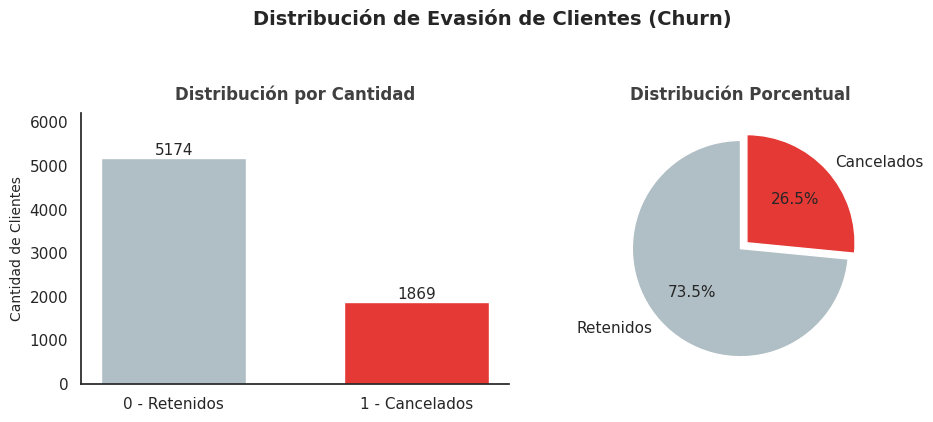


VERIFICACIÓN DE DESBALANCEO



,Estado,Cantidad,Porcentaje (%)
0,0 - Retenidos,5174,73.46
1,1 - Cancelados,1869,26.54



Ratio de desbalanceo: 2.77 a 1


In [67]:
print('PROPORCIÓN DE CANCELACIÓN\n\n')

# Cálculo de proporciones y ratio de desbalanceo
conteo = df_encoded['churn'].value_counts()
proporcion = df_encoded['churn'].value_counts(normalize=True) * 100
ratio = conteo[0] / conteo[1]

# Estética (gris retención - rojo evasión)
colores_alerta = ['#B0BEC5', '#E53935']
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribución de Evasión de Clientes (Churn)', fontsize=14, fontweight='bold', y=1.05)

# Grafico de Barras (cantidades)
axes[0].bar(['0 - Retenidos', '1 - Cancelados'], conteo.values, color=colores_alerta, width=0.6)
axes[0].set_title('Distribución por Cantidad', fontsize=12, pad=10, fontweight='bold', color='#404040')
axes[0].set_ylabel('Cantidad de Clientes', fontsize=10)
axes[0].set_ylim(0, conteo.max() * 1.20)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontsize=11)

# Gráfico de Torta (porcentaje)
axes[1].pie(conteo.values, labels=['Retenidos', 'Cancelados'],
            autopct='%1.1f%%', colors=colores_alerta, startangle=90,
            explode=(0, 0.08), textprops={'fontsize': 11})
axes[1].set_title('Distribución Porcentual', fontsize=12, pad=10, fontweight='bold', color='#404040')

plt.tight_layout()
plt.show()


# RESUMEN
print("\nVERIFICACIÓN DE DESBALANCEO\n")
resumen = pd.DataFrame({
    'Estado': ['0 - Retenidos', '1 - Cancelados'],
    'Cantidad': conteo.values,
    'Porcentaje (%)': proporcion.values.round(2)
})
display(resumen)

print(f"\nRatio de desbalanceo: {ratio:.2f} a 1")

**Interpretación de los resultados:**

Se identifica un **desbalanceo moderado** en el dataset, con un ratio aproximado de **2.7 a 1**. Esto indica que por cada cliente que cancela el servicio (clase minoritaria), existen casi tres clientes que permanecen activos (**clase mayoritaria - Retención**).

* **Observación:** la mayor proporción de clientes en la clase de Retención podría sesgar las métricas de desempeño si no se trata adecuadamente.
* **Decisión:** se aplicará la técnica de balanceo **SMOTE** en la siguiente etapa para equilibrar las clases y mejorar la capacidad del modelo para detectar la clase minoritaria (evasión).

### 1.5 Balanceo de clases

Se identifica la necesidad de aplicar técnicas de balanceo para mejorar la capacidad predictiva del modelo de detectar a la clase minoritaria (Evasión).

Para evitar la fuga de datos (Data Leakage), se aplicará la **técnica SMOTE** luego de la separación de los datos en entrenamiento y prueba (Punto 3.1). De esta manera, el balanceo se realizará exclusivamente sobre el conjunto de entrenamiento, garantizando que el grupo de prueba permanezca con datos reales y no contaminados por registros sintéticos.

### 1.6 Estandarización de Variables Numéricas

Se evalúa la necesidad de transformar los datos según los algoritmos seleccionados para la etapa de modelado:

* **Regresión Logística:** es un modelo lineal paramétrico, sensible a la magnitud de las variables. El proceso de estandarización permite evitar que las variables con valores numéricos más altos influyan desproporcionadamente en el cálculo de los coeficientes.
* **Random Forest:** al estar basado en árboles de decisión, no es sensible a la escala de los datos. No obstante, aplicar esta transformación no afecta negativamente su rendimiento.

Para cumplir con este preprocesamiento, se aplica la técnica StandardScaler sobre las variables numéricas continuas. Este método utiliza el cálculo de Z-score para centrar la media en 0 y la desviación estándar en 1, manteniendo sin modificación las variables categóricas y binarias tratadas previamente.

**Fórmula:** z = (x - μ) / σ

**Variables a estandarizar:**
* `tenure` (0–72 meses)
* `monthly_charges` (~$18–$119)

<br>



ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS




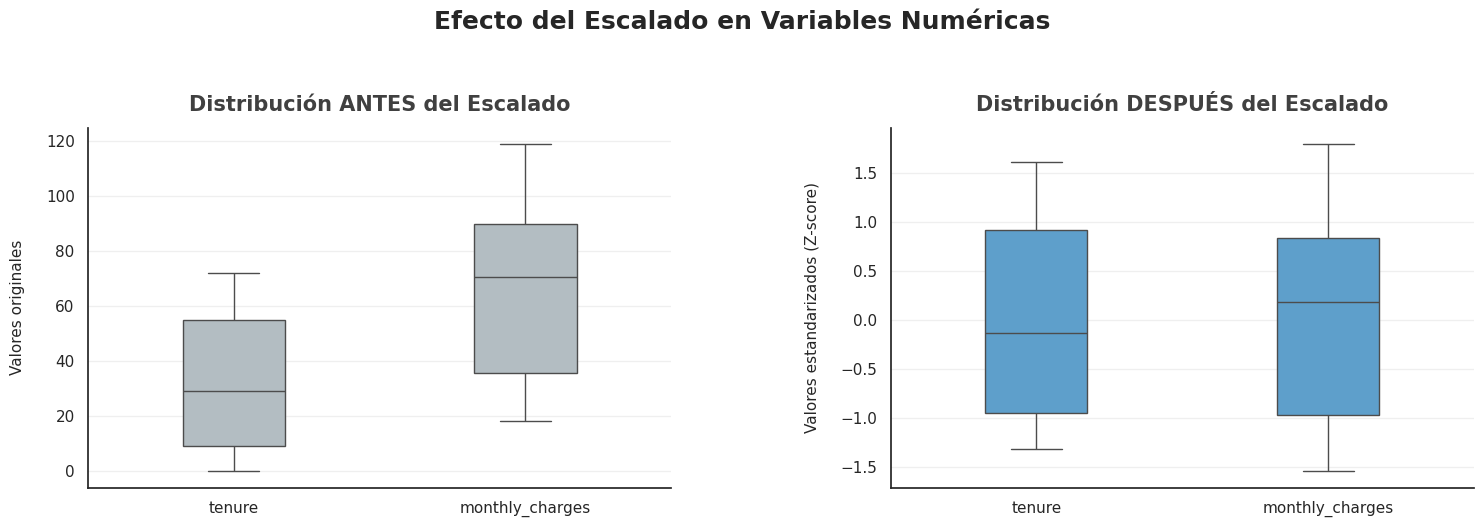



 ESTADÍSTICAS DESPUÉS DEL ESCALADO (Z-score)



,tenure,monthly_charges
count,7043.00,7043.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.32,-1.55
25%,-0.95,-0.97
50%,-0.14,0.19
75%,0.92,0.83
max,1.61,1.79



Verificación de estandarización:
   • tenure              : Media = -0.000, Std =  1.000
   • monthly_charges     : Media = -0.000, Std =  1.000


In [68]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print('ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS\n\n')

# se identifican las variables numéricas continuas a escalar
vars_num = [col for col in df_encoded.columns if df_encoded[col].nunique() > 2 and col != 'churn']

# se crea una copia del dataframe para la etapa de modelado
df_ml = df_encoded.copy()

# se aplica la estandarización
scaler = StandardScaler()
df_ml[vars_num] = scaler.fit_transform(df_ml[vars_num])

# estética del gráfico
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Efecto del Escalado en Variables Numéricas', fontsize=18, fontweight='bold', y=1.05)

# Gráfico 1: Antes del escalado
sns.boxplot(data=df_encoded[vars_num], ax=axes[0], color='#B0BEC5', width=0.35)
axes[0].set_title('Distribución ANTES del Escalado', fontsize=15, pad=12, fontweight='bold', color='#404040')
axes[0].set_ylabel('Valores originales', fontsize=11, labelpad=15)
axes[0].tick_params(labelsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Después del escalado
sns.boxplot(data=df_ml[vars_num], ax=axes[1], color='#4CA3DD', width=0.35)
axes[1].set_title('Distribución DESPUÉS del Escalado', fontsize=15, pad=12, fontweight='bold', color='#404040')
axes[1].set_ylabel('Valores estandarizados (Z-score)', fontsize=11, labelpad=15)
axes[1].tick_params(labelsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(w_pad=8.0)
plt.show()

# Resumen estadístico
print("\n\n ESTADÍSTICAS DESPUÉS DEL ESCALADO (Z-score)\n")
display(df_ml[vars_num].describe().round(2))

# Verificación de estandarización
print("\nVerificación de estandarización:")
for var in vars_num:
    media = df_ml[var].mean()
    std = df_ml[var].std()
    print(f"   • {var:20s}: Media = {media:6.3f}, Std = {std:6.3f}")

**Resumen de Preparación:**

El dataset fue preparado para la etapa de modelado mediante los siguientes pasos:

(1) eliminación de 6 columnas irrelevantes o con problemas de multicolinealidad.

(2) encoding de las variables categóricas, generando variables dummy (0 y 1).

(3) identificación de desbalanceo moderado en la variable objetivo (será corregido con la técnica SMOTE en el Punto 3.1, tras la división de train/test).

(4) estandarización de 2 variables continuas (`tenure` y `monthly_charges`) mediante Z-score.

El dataset final consolidado contiene **7,043 registros con 28 features** listos para entrenar los modelos de clasificación.

## 📊 <font color=green>  2. Correlación y Selección de Variables </font>

A partir del dataset preparado y estandarizado, se analizan las relaciones entre las variables para identificar aquellas con mayor poder predictivo sobre la evasión de clientes. El análisis se estructura en dos componentes:

1. **Análisis de Correlación**: se visualiza la matriz de correlación de Pearson para cuantificar la fuerza de la relación lineal entre las variables numéricas y el *churn*.
2. **Análisis Dirigido**: se investiga mediante visualizaciones específicas (boxplots) cómo se comportan estas variables clave frente a la cancelación, observando patrones que el coeficiente lineal podría no capturar.

### 2.1 Análisis de Correlación

Se calcula el coeficiente de correlación para identificar qué factores presentan una relación directa o inversa con la cancelación de servicios. Este análisis permite comprender el impacto de cada variable en el comportamiento de los clientes y seleccionar las más relevantes para el modelado.

Las variables seleccionadas para este análisis incluyen:
* **Numéricas continuas:** `tenure`, `monthly_charges`
* **Binarias demográficas:** `senior_citizen`, `partner`, `dependents`.
* **Variable objetivo:** `churn`.

MATRIZ DE CORRELACIÓN: VARIABLES SELECCIONADAS VS. CHURN




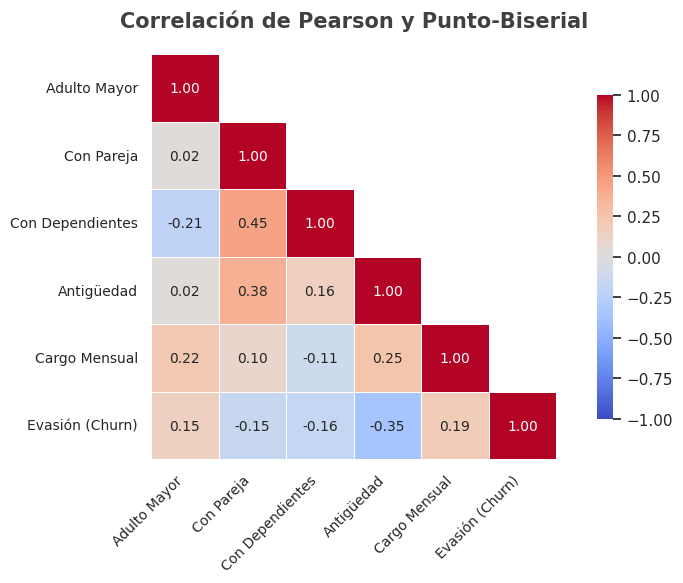



RANKING DE CORRELACIÓN CON LA EVASIÓN (CHURN)

  • Cargo Mensual     : +0.193
  • Adulto Mayor      : +0.151
  • Con Pareja        : -0.150
  • Con Dependientes  : -0.164
  • Antigüedad        : -0.352


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('MATRIZ DE CORRELACIÓN: VARIABLES SELECCIONADAS VS. CHURN\n\n')

# seleccionar variables para correlación (estandarizadas + binarias)
vars_corr = ['senior_citizen', 'partner', 'dependents',
             'tenure', 'monthly_charges', 'churn']

# nombres legibles para el gráfico
nombres = {
    'senior_citizen': 'Adulto Mayor',
    'partner': 'Con Pareja',
    'dependents': 'Con Dependientes',
    'tenure': 'Antigüedad',
    'monthly_charges': 'Cargo Mensual',
    'churn': 'Evasión (Churn)'
}

# calcular matriz de correlación
matriz_corr = df_ml[vars_corr].corr()
matriz_corr = matriz_corr.rename(columns=nombres, index=nombres)

# configurar gráfico
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool), k=1)

# Heatmap
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10}, ax=ax)

ax.set_title("Correlación de Pearson y Punto-Biserial",
             fontsize=15, fontweight='bold', pad=20, color='#404040')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


# Ranking de correlación con churn
print('\n\nRANKING DE CORRELACIÓN CON LA EVASIÓN (CHURN)\n')

# se filtra columna churn y se ordena
corr_churn = matriz_corr['Evasión (Churn)'].drop('Evasión (Churn)').sort_values(ascending=False)
for var, valor in corr_churn.items():
    signo = "+" if valor > 0 else ""
    print(f"  • {var:18s}: {signo}{valor:.3f}")


**Interpretación de la Matriz de Correlación:**

El análisis permite identificar las variables que presentan mayor relación lineal con la evasión de clientes (churn):

* **Antigüedad (-0.352):** muestra la correlación negativa más alta con el churn. Esto indica que a mayor tiempo de permanencia del cliente en la empresa, la probabilidad de abandono disminuye drásticamente, lo cual confirma que los primeros meses son críticos.

* **Demografía (-0.164 a -0.150):** variables como tener dependientes o pareja presentan correlaciones negativas con el churn. Esto sugiere que la estabilidad familiar se asocia con una mayor fidelización y menores niveles de cancelación del servicio de telecomunicaciones.

* **Cargo Mensual (+0.193):** presenta una correlación positiva con el churn, lo que indica que los planes con costos más elevados pueden asociarse con una mayor tendencia al abandono. Esto podría sugerir una sensibilidad al precio o insatisfacción con el valor percibido.

* **Adulto Mayor (+0.151):** los clientes mayores (*senior citizens*) muestran una ligera mayor tendencia a cancelar el servicio en comparación con los demás clientes.


Tras la eliminación de variables redundantes en la Fase 1, no se observan niveles elevados de multicolinealidad entre las variables predictoras, por lo que pueden incluirse simultáneamente en los modelos sin generar problemas significativos de redundancia.

<br>


### 2.2 Análisis Dirigido: Distribución de Variables Clave

Se profundiza el análisis de las principales variables numéricas en relación con la evasión de clientes (*churn*) mediante visualizaciones que permiten observar las diferencias entre los clientes que permanecen y los que cancelan el servicio.

Para este análisis **se utilizan los datos en su escala original** (previo a la estandarización) para facilitar la interpretación directa en términos de negocio (meses reales y dólares exactos).

Se analizan dos factores críticos (`tenure` y `monthly_charges`) utilizando las siguientes herramientas gráficas:
- **Boxplots:** permiten identificar la mediana, la dispersión de los datos y la presencia de valores atípicos.
- **Histogramas superpuestos:** permiten comparar la distribución de frecuencias entre los clientes retenidos y aquellos que abandonaron el servicio.

#### 2.2.1 Antigüedad vs Churn

ANÁLISIS DIRIGIDO: ANTIGÜEDAD VS CHURN




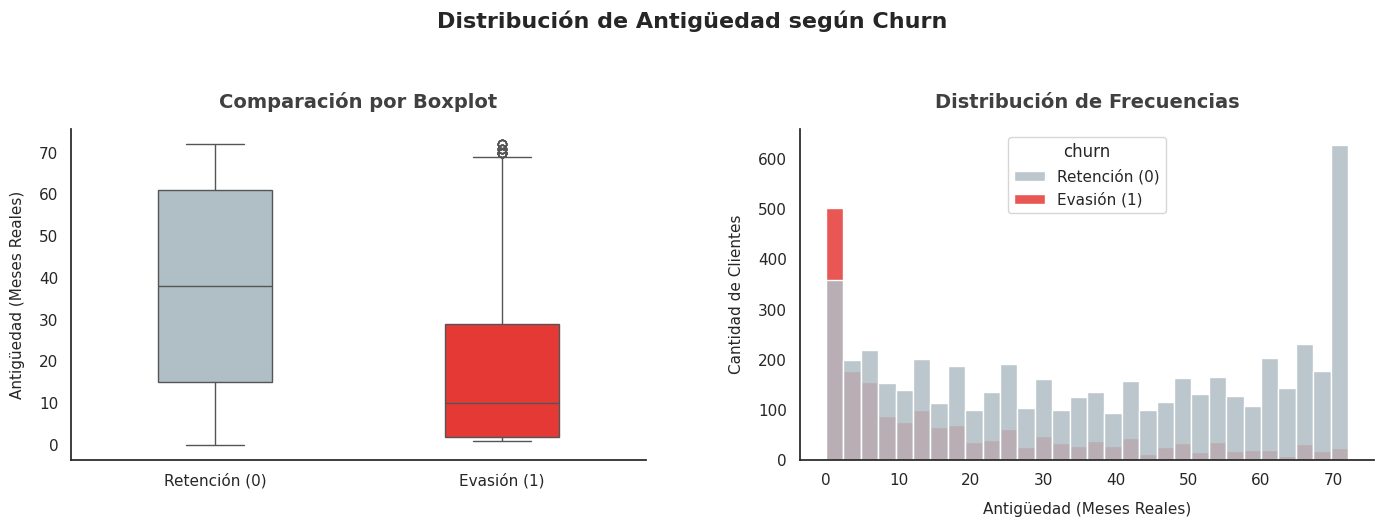


Promedio de Antigüedad (Meses):
  • Retención : 37.6 meses
  • Evasión   : 18.0 meses
  • Diferencia: 19.6 meses



In [70]:
print('ANÁLISIS DIRIGIDO: ANTIGÜEDAD VS CHURN\n\n')

# colores (gris retención - rojo evasión)
colores_alerta = ['#B0BEC5', '#E53935']

# lienzo
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Antigüedad según Churn', fontsize=16, fontweight='bold', y=1.05)

# Gráfico Boxplot
sns.boxplot(x='churn', y='tenure', data=df_encoded, ax=axes[0],
            hue='churn', palette=colores_alerta, width=0.4,
            saturation=1, legend=False)

axes[0].set_title('Comparación por Boxplot', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Antigüedad (Meses Reales)', fontsize=11, labelpad=10)
axes[0].tick_params(labelsize=11)
sns.despine(ax=axes[0])

# Gráfico Histograma superpuesto
sns.histplot(data=df_encoded, x='tenure', hue='churn', bins=30, ax=axes[1],
             palette=colores_alerta, kde=False, alpha=0.85, stat='count')

axes[1].set_title('Distribución de Frecuencias', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[1].set_xlabel('Antigüedad (Meses Reales)', fontsize=11, labelpad=10)
axes[1].set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=10)
axes[1].tick_params(labelsize=11)

# leyenda
leyenda = axes[1].get_legend()
if leyenda:
    for t, l in zip(leyenda.texts, ['Retención (0)', 'Evasión (1)']):
        t.set_text(l)

sns.despine(ax=axes[1])

plt.tight_layout(w_pad=5.0)
plt.show()

# mostrar estadísticas
media_ret = df_encoded[df_encoded['churn'] == 0]['tenure'].mean()
media_ev = df_encoded[df_encoded['churn'] == 1]['tenure'].mean()
print(f'\nPromedio de Antigüedad (Meses):')
print(f'  • Retención : {media_ret:.1f} meses')
print(f'  • Evasión   : {media_ev:.1f} meses')
print(f'  • Diferencia: {abs(media_ret - media_ev):.1f} meses\n')


**Observación:** los clientes que cancelan el servicio tienen, en promedio, cerca de la mitad de la antigüedad (18 meses) que aquellos que permanecen en la compañía (aproximadamente 38 meses). El gráfico sugiere que el riesgo de abandono es bastante mayor durante los primeros meses de contrato, mientras que la retención tiende a estabilizarse a medida que el cliente supera el primer año y medio de permanencia.

#### 2.2.2 Cargo Mensual vs Churn

ANÁLISIS DIRIGIDO: CARGO MENSUAL VS CHURN




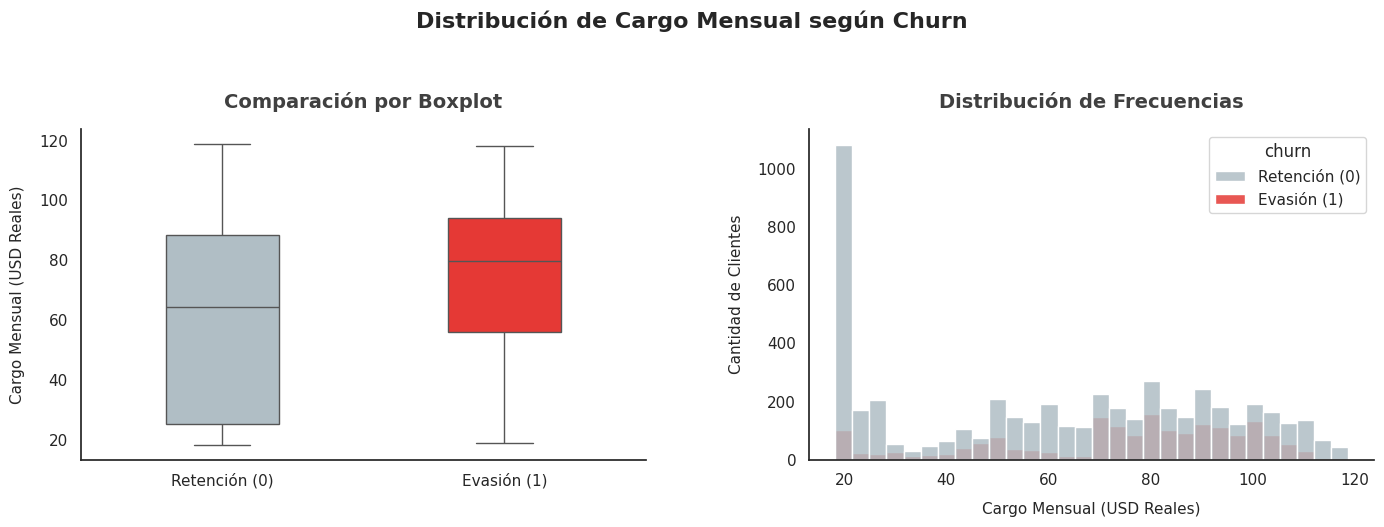


Promedio de Cargo Mensual:
  • Retención : $61.27
  • Evasión   : $74.44
  • Diferencia: $13.18



In [71]:
print('ANÁLISIS DIRIGIDO: CARGO MENSUAL VS CHURN\n\n')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Cargo Mensual según Churn', fontsize=16, fontweight='bold', y=1.05)

# Gráfico Boxplot
sns.boxplot(x='churn', y='monthly_charges', data=df_encoded, ax=axes[0],
            hue='churn', palette=colores_alerta, width=0.4,
            saturation=1, legend=False)

axes[0].set_title('Comparación por Boxplot', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Cargo Mensual (USD Reales)', fontsize=11, labelpad=10)
axes[0].tick_params(labelsize=11)
sns.despine(ax=axes[0])

# Gráfico Histograma superpuesto
sns.histplot(data=df_encoded, x='monthly_charges', hue='churn', bins=30, ax=axes[1],
             palette=colores_alerta, kde=False, alpha=0.85)

axes[1].set_title('Distribución de Frecuencias', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[1].set_xlabel('Cargo Mensual (USD Reales)', fontsize=11, labelpad=10)
axes[1].set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=10)
axes[1].tick_params(labelsize=11)

# leyenda
leyenda = axes[1].get_legend()
if leyenda:
    for t, l in zip(leyenda.texts, ['Retención (0)', 'Evasión (1)']):
        t.set_text(l)

sns.despine(ax=axes[1])

plt.tight_layout(w_pad=5.0)
plt.show()


# mmostrar estadísticas
media_ret = df_encoded[df_encoded['churn'] == 0]['monthly_charges'].mean()
media_ev = df_encoded[df_encoded['churn'] == 1]['monthly_charges'].mean()
print(f'\nPromedio de Cargo Mensual:')
print(f'  • Retención : ${media_ret:.2f}')
print(f'  • Evasión   : ${media_ev:.2f}')
print(f'  • Diferencia: ${abs(media_ev - media_ret):.2f}\n')


**Observación:** Los clientes que cancelan el servicio pagan en promedio alrededor de \$13 dólares más por mes que los clientes retenidos. El histograma muestra que la retención es más frecuente en los planes de menor costo (cerca de los \$20), mientras que las cancelaciones tienden a concentrarse en los planes más caros.

### Conclusión de la Fase de Correlación y Selección

El análisis conjunto de correlación y las visualizaciones detalladas permiten identificar tres patrones principales asociados al abandono de clientes:

1. **Impacto de la Antigüedad:** los primeros meses representan el período más crítico. Los clientes nuevos presentan mayores niveles de abandono, mientras que la retención aumenta significativamente a medida que crece la permanencia, estabilizándose una vez superado el primer año y medio de contrato.

2. **Peso del Cargo Mensual:** los clientes con planes más costosos (especialmente por encima de los $70) presentan una mayor tendencia a cancelar el servicio, lo que podría reflejar sensibilidad al precio o menor percepción de valor en los servicios de mayor costo.

3. **Factores Demográficos:** variables como tener pareja o dependientes muestran una relación negativa con el *churn*, sugiriendo que los clientes con mayor estabilidad familiar tienden a presentar menores niveles de cancelación. En contraste, los adultos mayores muestran una ligera mayor propensión al abandono.


**Decisión para el modelado:**  dado que estas variables muestran relación con la cancelación y no se detecta multicolinealidad severa entre los predictores, se conservarán para la etapa de modelado.

El dataset final contiene **7,043 registros y 28 variables** , que serán utilizados para avanzar a la Fase 3 de Modelado Predictivo.

<br>


## 🔍 <font color=green> 3. Modelado Predictivo </font>

En esta fase se construyen y evalúan distintos algoritmos de *Machine Learning* para predecir la probabilidad de que un cliente cancele su servicio.

**Selección de Modelos**
Para este análisis se implementan dos modelos de clasificación con enfoques distintos:

1. **Regresión Logística:** es un modelo paramétrico que estima probabilidades mediante una función sigmoide. Debido a que calcula los coeficientes a partir de la magnitud de las variables, es sensible a la escala de los datos. Por este motivo, requiere que las variables numéricas estén estandarizadas para evitar que aquellas con altos valores influyan desproporcionadamente en el modelo, sesgando los resultados.

2. **Random Forest:** es un modelo de ensamble basado en árboles de decisión. Su funcionamiento se basa en divisiones por umbrales (mayor o menor que cierto valor), por lo que no depende de distancias matemáticas entre variables y, en general, no requiere estandarización.



*Estrategia aplicada:* para mantener coherencia en el proceso y facilitar la comparación entre modelos bajo las mismas condiciones, se utilizará el dataset `df_ml` preparado en la Fase 1, que ya contiene las variables numéricas estandarizadas mediante *Z-score*. Aunque Random Forest no necesita este escalado, su uso no afecta negativamente su rendimiento.

### 3.1 Separación de Datos y Balanceo de Clases

El dataset se divide en un conjunto de entrenamiento (70%), utilizado para que los modelos aprendan los patrones, y un conjunto de prueba (30%), destinado a evaluar su rendimiento sobre nuevos datos. Se utiliza el parámetro `stratify` para mantener la proporción original de churn en ambas particiones.

Posteriormente, se aborda el desbalance moderado de clases detectado en el Punto 1.4 (73% retención vs 26% evasión). Para reducir este sesgo hacia la clase mayoritaria se aplica la técnica **SMOTE (Synthetic Minority Over-sampling Technique)** exclusivamente sobre el conjunto de entrenamiento. Esto evita la filtración de información hacia el conjunto de prueba (*data leakage*), permitiendo evaluar el modelo de forma más realista sobre datos con distribución original.

DIVISIÓN DE DATOS Y BALANCEO (SMOTE)

Dimensiones originales:
  • Entrenamiento : 4930 registros
  • Prueba        : 2113 registros

Dimensiones con SMOTE aplicadas:
  • Entrenamiento : 7244 registros (Balanceado)



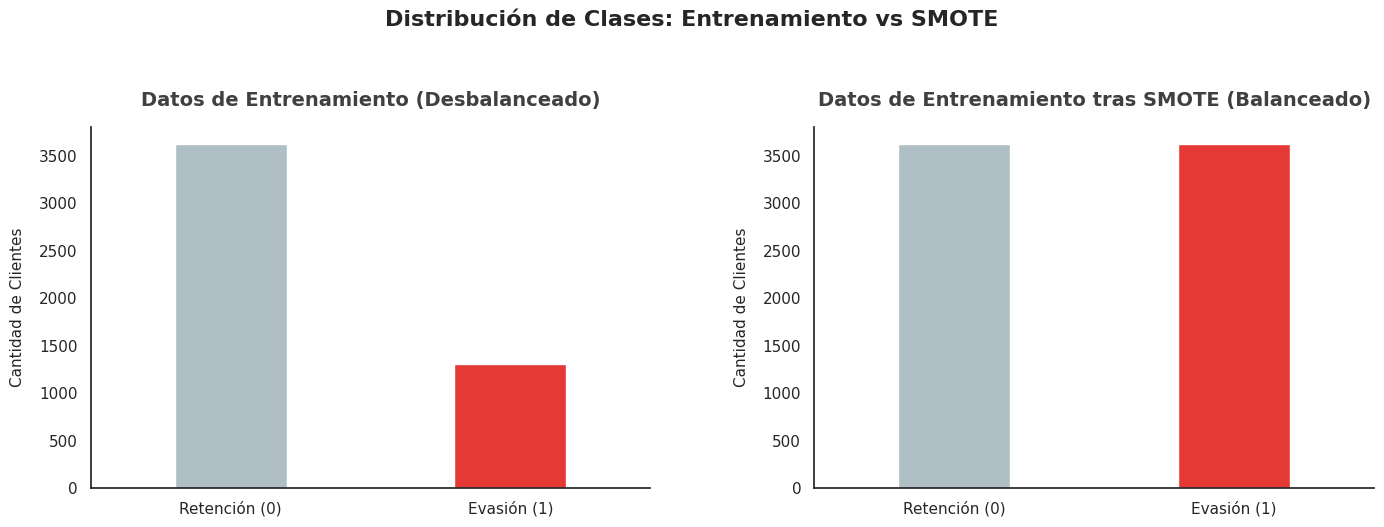


Distribución de Clases en Entrenamiento 
Antes de SMOTE : Retención = 3622 | Evasión = 1308
Tras SMOTE     : Retención = 3622 | Evasión = 3622



In [72]:
print('DIVISIÓN DE DATOS Y BALANCEO (SMOTE)\n')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Separación de variables predictoras (X) y objetivo (y)
# (df_ml con variables estandarizadas)
X = df_ml.drop('churn', axis=1)
y = df_ml['churn']

# división en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones originales:")
print(f"  • Entrenamiento : {X_train.shape[0]} registros")
print(f"  • Prueba        : {X_test.shape[0]} registros\n")

# aplicar SMOTE (solo en entrenamiento)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Dimensiones con SMOTE aplicadas:")
print(f"  • Entrenamiento : {X_train_sm.shape[0]} registros (Balanceado)\n")

# gráfico de impacto de SMOTE
colores_alerta = ['#B0BEC5', '#E53935']
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases: Entrenamiento vs SMOTE', fontsize=16, fontweight='bold', y=1.05)

# gráfico 1: antes (y_train)
sns.countplot(x=y_train, ax=axes[0], palette=colores_alerta, width=0.4, saturation=1, legend=False, hue=y_train)
axes[0].set_title('Datos de Entrenamiento (Desbalanceado)', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=10)
axes[0].tick_params(labelsize=11)
sns.despine(ax=axes[0])

# gráfico 2: después (y_train_sm)
sns.countplot(x=y_train_sm, ax=axes[1], palette=colores_alerta, width=0.4, saturation=1, legend=False, hue=y_train_sm)
axes[1].set_title('Datos de Entrenamiento tras SMOTE (Balanceado)', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=10)
axes[1].tick_params(labelsize=11)
sns.despine(ax=axes[1])

plt.tight_layout(w_pad=5.0)
plt.show()

# mostrar resumen
print("\nDistribución de Clases en Entrenamiento ")
print(f"Antes de SMOTE : Retención = {sum(y_train==0)} | Evasión = {sum(y_train==1)}")
print(f"Tras SMOTE     : Retención = {sum(y_train_sm==0)} | Evasión = {sum(y_train_sm==1)}\n")


### 3.2 Creación y Entrenamiento de Modelos

Se seleccionan dos algoritmos de clasificación de distinta naturaleza para predecir la cancelación del servicio: **Regresión Logística** y **Random Forest**. Ambos modelos se entrenarán utilizando el conjunto de datos balanceado mediante SMOTE (`X_train_sm`, `y_train_sm`).

**Justificación del preprocesamiento (estandarización de variables):**

* **Regresión Logística:** es un modelo basado en la optimización de parámetros. Por este motivo requiere que las variables numéricas continuas estén estandarizadas. La transformación aplicada en la Fase 1 permite que los coeficientes se calculen correctamente y evita que variables con valores grandes (por ejemplo, `monthly_charges`) tengan un peso matemático desproporcionado frente a las variables categóricas que están codificadas simplemente con 0 y 1.

* **Random Forest:** es un modelo basado en árboles de decisión que realiza particiones de los datos mediante umbrales de valor. Por lo tanto, no depende de distancias matemáticas ni requiere escalado de variables. Sin embargo, entrenarlo con el dataset estandarizado no afecta su rendimiento y permite comparar ambos modelos bajo las mismas condiciones.


#### 3.2.1 Modelo 1: Regresión Logística

Se instancia y entrena un modelo de **Regresión Logística** utilizando el conjunto de entrenamiento balanceado.
Se configura el hiperparámetro `max_iter = 1000`  para asegurar que el algoritmo disponga de suficientes iteraciones para alcanzar la convergencia durante el entrenamiento.

In [73]:
from sklearn.linear_model import LogisticRegression
print('CREACIÓN Y ENTRENAMIENTO: REGRESIÓN LOGÍSTICA\n')

# crear la instancia del modelo
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

# entrenar el modelo con los datos balanceados
modelo_lr.fit(X_train_sm, y_train_sm)

# obtener predicciones sobre los datos de prueba
y_pred_lr = modelo_lr.predict(X_test)

print("Modelo de Regresión Logística entrenado con éxito.")
print(f"   • Predicciones generadas para los {len(y_pred_lr)} registros de prueba.")


CREACIÓN Y ENTRENAMIENTO: REGRESIÓN LOGÍSTICA

Modelo de Regresión Logística entrenado con éxito.
   • Predicciones generadas para los 2113 registros de prueba.


#### 3.2.2 Modelo 2: Random Forest

Se instancia y entrena un modelo **Random Forest Classifier** utilizando el conjunto de entrenamiento balanceado.
Se define la semilla `random_state = 42` para garantizar la reproducibilidad de los resultados obtenidos durante el entrenamiento.

In [74]:
from sklearn.ensemble import RandomForestClassifier
print('CREACIÓN Y ENTRENAMIENTO: RANDOM FOREST\n')

# crear la instancia del modelo
modelo_rf = RandomForestClassifier(random_state=42)

# entrenar el modelo con los datos balanceados
modelo_rf.fit(X_train_sm, y_train_sm)

# obtener predicciones sobre los datos de prueba
y_pred_rf = modelo_rf.predict(X_test)

print("Modelo Random Forest entrenado con éxito.")
print(f"   • Predicciones generadas para los {len(y_pred_rf)} registros de prueba.")


CREACIÓN Y ENTRENAMIENTO: RANDOM FOREST

Modelo Random Forest entrenado con éxito.
   • Predicciones generadas para los 2113 registros de prueba.


### 3.3 Evaluación de los Modelos

En esta etapa se evalúa el desempeño de los modelos entrenados utilizando el conjunto de prueba (Test), compuesto por datos que el algoritmo no ha utilizado durante el entrenamiento. Para ello se emplean las siguientes métricas de evaluación:

* **Matriz de Confusión:** para visualizar los aciertos del modelo y los distintos tipos de error (falsos positivos y falsos negativos).

* **Exactitud (Accuracy):** porcentaje total de predicciones correctas sobre el total de observaciones.

* **Precisión (Precision):** proporción de clientes identificados como "Evasión" que efectivamente cancelaron el servicio.

* **Sensibilidad (Recall):** capacidad del modelo para identificar a todos los clientes que realmente cancelaron.

* **F1-Score:** media armónica que busca un equilibrio entre la Precisión y el Recall.

Adicionalmente, se calculará la **exactitud sobre los datos de entrenamiento** con el objetivo de detectar posibles problemas de **underfitting** (subajuste) o **overfitting** (sobreajuste).

MATRIZ DE CONFUSIÓN: COMPARACIÓN DE MODELOS




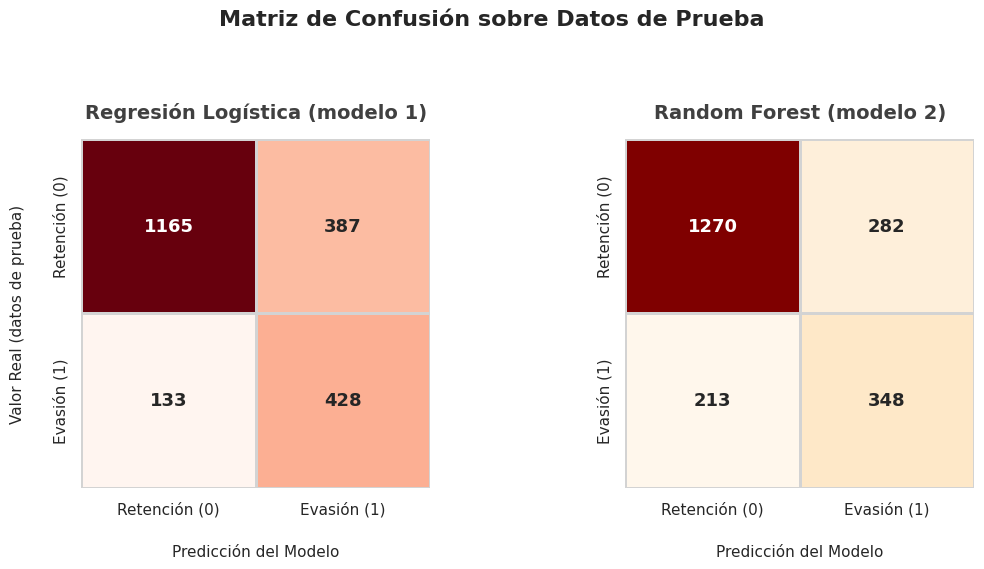



Métricas de desempeño (en los datos de prueba)



,Métrica,Regresión Logística,Random Forest
0,1. Exactitud (Accuracy),0.754,0.766
1,2. Precisión,0.525,0.552
2,3. Sensibilidad (Recall),0.763,0.620
3,4. F1-Score,0.622,0.584




Análisis de sobreajuste (OVERFITTING)
• Regresión Logística -> Exactitud en Entrenamiento: 0.795 | En Prueba: 0.754
• Random Forest       -> Exactitud en Entrenamiento: 0.998 | En Prueba: 0.766



In [75]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1) mostrar matrices de confusión de cada modelo
print('MATRIZ DE CONFUSIÓN: COMPARACIÓN DE MODELOS\n\n')

# calcular matrices de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# lienzo
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))
fig.suptitle('Matriz de Confusión sobre Datos de Prueba', fontsize=16, fontweight='bold', y=1.05)

# Gráfico modelo 1: Regresión Logística (Rojos)
# Se agrega linewidths y linecolor para los bordes
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar=False, square=True,
            annot_kws={"size": 13, "weight": "bold"}, linewidths=1, linecolor='lightgray')
axes[0].set_title('Regresión Logística (modelo 1)', fontsize=14, pad=15, fontweight='bold', color='#404040')
axes[0].set_xlabel('Predicción del Modelo', fontsize=11, labelpad=20)
axes[0].set_ylabel('Valor Real (datos de prueba)', fontsize=11, labelpad=20)
axes[0].set_xticklabels(['Retención (0)', 'Evasión (1)'])
axes[0].set_yticklabels(['Retención (0)', 'Evasión (1)'])

# Gráfico modelo 2: Random Forest (Naranjas/Rojos)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='OrRd', ax=axes[1], cbar=False, square=True,
            annot_kws={"size": 13, "weight": "bold"}, linewidths=1, linecolor='lightgray')
axes[1].set_title('Random Forest (modelo 2)', fontsize=14, pad=15, fontweight='bold', color='#404040')
axes[1].set_xlabel('Predicción del Modelo', fontsize=11, labelpad=20)
axes[1].set_ylabel('')
axes[1].set_xticklabels(['Retención (0)', 'Evasión (1)'])
axes[1].set_yticklabels(['Retención (0)', 'Evasión (1)'])

plt.tight_layout(w_pad=10.0)
plt.show()

# 2) métricas de desempeño
print('\n\nMétricas de desempeño (en los datos de prueba)\n')

def calcular_metricas(y_real, y_pred):
    return [
        accuracy_score(y_real, y_pred),
        precision_score(y_real, y_pred),
        recall_score(y_real, y_pred),
        f1_score(y_real, y_pred)
    ]

# crear df comparativo
df_metricas = pd.DataFrame({
    'Métrica': ['1. Exactitud (Accuracy)', '2. Precisión', '3. Sensibilidad (Recall)', '4. F1-Score'],
    'Regresión Logística': calcular_metricas(y_test, y_pred_lr),
    'Random Forest': calcular_metricas(y_test, y_pred_rf)
})

# redondear a 3 decimales
df_metricas.iloc[:, 1:] = df_metricas.iloc[:, 1:].round(3)
display(df_metricas)

# 3) verificación sobreajuste (Overfitting)
print('\n\nAnálisis de sobreajuste (OVERFITTING)')

# accuracy en datos de entrenamiento
acc_train_lr = accuracy_score(y_train_sm, modelo_lr.predict(X_train_sm))
acc_train_rf = accuracy_score(y_train_sm, modelo_rf.predict(X_train_sm))
print(f"• Regresión Logística -> Exactitud en Entrenamiento: {acc_train_lr:.3f} | En Prueba: {df_metricas.iloc[0, 1]:.3f}")
print(f"• Random Forest       -> Exactitud en Entrenamiento: {acc_train_rf:.3f} | En Prueba: {df_metricas.iloc[0, 2]:.3f}\n")

### 3.3 Análisis Crítico y Comparación de Modelos

Al evaluar el desempeño sobre los datos de prueba, la **Regresión Logística** demuestra ser el modelo más efectivo y alineado a los objetivos comerciales de Telecom X, a pesar de que el **Random Forest** presenta una Exactitud (Accuracy) levemente superior (76.6% frente a 75.4%).

Esta decisión se basa principalmente en el análisis de la **Sensibilidad (Recall)**. En un problema de retención de clientes (*churn*), el objetivo central es minimizar los **falsos negativos**, es decir, los casos en los que un cliente cancela el servicio sin ser identificado previamente por el modelo. En este sentido, la Regresión Logística alcanza un Recall del **76.3%**, lo que significa que logra identificar aproximadamente a **3 de cada 4 clientes que realmente abandonan el servicio**. El Random Forest, en cambio, obtiene solo un **62.0%** en esta métrica, lo que implica que una proporción mayor de clientes en riesgo (casi el 38%) no sería detectada por el modelo.

Por otro lado, el Random Forest presenta una **Precisión** ligeramente superior (55.2% frente al 52.5% de la Regresión Logística), lo que indica que comete menos falsos positivos. Sin embargo, en el contexto de las telecomunicaciones suele considerarse más costoso **no detectar a un cliente que está por cancelar** que ofrecer una acción preventiva a un usuario que no pensaba en irse. Este equilibrio superior de la Regresión Logística entre precisión y sensibilidad también se refleja en el **F1-Score**, que lidera con un valor de **0.622** frente al **0.584** alcanzado por el Random Forest.

En cuanto a la capacidad de generalización, el **Random Forest muestra señales de overfitting (sobreajuste)**. Durante el entrenamiento con los datos balanceados mediante SMOTE, el modelo alcanzó una exactitud cercana al **100%** (99.8%), pero su rendimiento disminuyó al evaluarse sobre el conjunto de prueba (76.6%). Esto sugiere que el modelo pudo haber aprendido en exceso las características específicas del conjunto de entrenamiento, incluyendo parte del ruido o de las muestras sintéticas generadas por el balanceo, en lugar de aprender el patrón real. Para corregir este problema en futuras iteraciones, podrían ajustarse algunos hiperparámetros del modelo, como limitar la profundidad máxima de los árboles (`max_depth`) o aumentar el número mínimo de muestras necesarias para realizar una división (`min_samples_split`).

La **Regresión Logística**, en cambio, presenta resultados más consistentes entre su fase de entrenamiento (79.5%) y la de prueba (75.4%). Esta estabilidad sugiere que el modelo logra capturar patrones generales de los datos sin presentar síntomas de *overfitting* ni de *underfitting*, convirtiéndose en un modelo robusto y apto para ser implementado en estrategias de retención.

## <font color=green>  📄 4. Interpretación y Conclusiones


### 4.1 Análisis de Importancia de Variables

En esta fase final se analiza la contribución de cada variable en las predicciones de los modelos entrenados. Este análisis permite identificar los factores que influyen en la evasión de clientes y respaldar las decisiones comerciales que se proponen en el informe final.

Para ello se extraen dos tipos de información complementaria:

* **Coeficientes de Regresión Logística:** indican la dirección (positiva o negativa) y la magnitud del impacto de cada variable sobre la probabilidad de cancelación del servicio.


* **Importancia Relativa en Random Forest:** mide qué tan relevante fue cada variable en las decisiones de división de los árboles del modelo, evaluando su contribución general sin considerar la dirección del efecto.

Las variables más relevantes en ambos modelos pueden considerarse factores de riesgo más robustos, ya que su importancia se mantiene independientemente del algoritmo utilizado. Estos resultados servirán como base para el análisis final y las recomendaciones de retención.

ANÁLISIS DE IMPORTANCIA DE VARIABLES




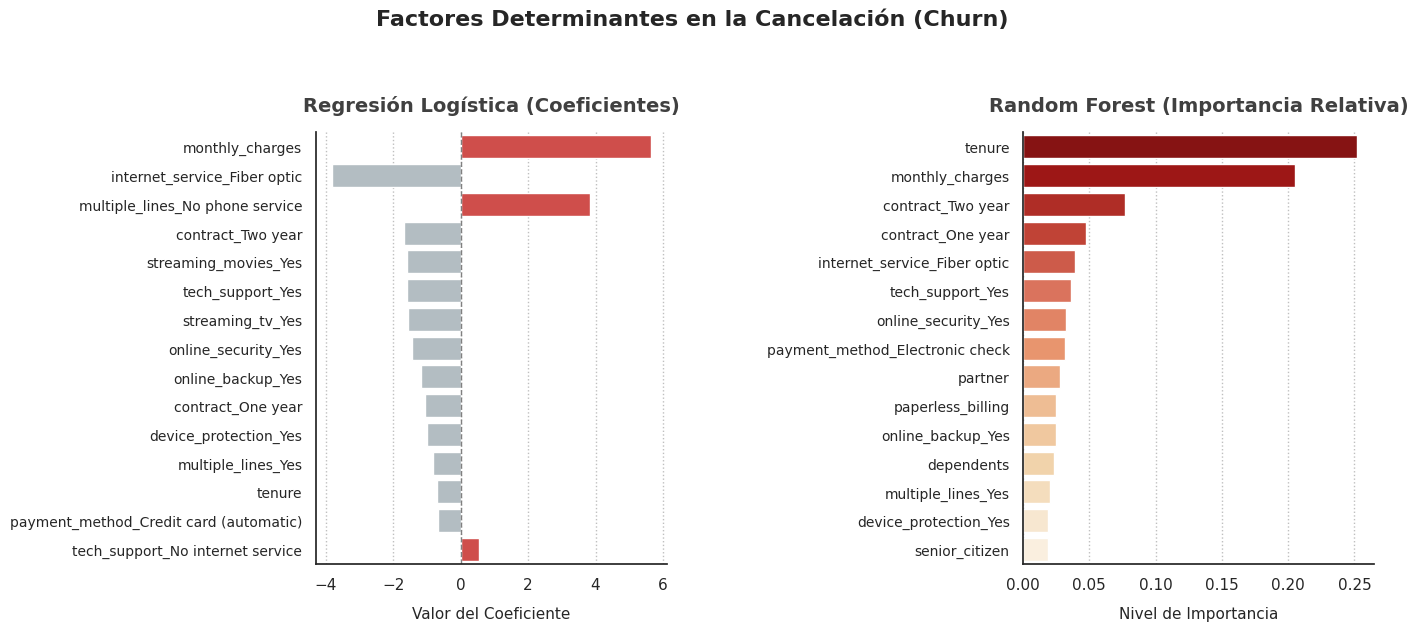


Interpretación Visual:
  • Barras ROJAS (Regresión): aumentan el riesgo de evasión (coeficiente positivo).
  • Barras GRISES (Regresión): actúan como barreras de retención (coeficiente negativo).


COMPARACIÓN: VARIABLES CLAVE IDENTIFICADAS POR AMBOS MODELOS

Variables relevantes identificadas por ambos modelos (TOP 10):
  • contract_One year         | Regresión: -1.065 (↓ menor probabilidad de churn) | Random Forest: 0.0474
  • contract_Two year         | Regresión: -1.688 (↓ menor probabilidad de churn) | Random Forest: 0.0772
  • internet_service_Fiber optic | Regresión: -3.836 (↓ menor probabilidad de churn) | Random Forest: 0.0394
  • monthly_charges           | Regresión: +5.636 (↑ mayor probabilidad de churn) | Random Forest: 0.2055
  • online_security_Yes       | Regresión: -1.434 (↓ menor probabilidad de churn) | Random Forest: 0.0323
  • tech_support_Yes          | Regresión: -1.589 (↓ menor probabilidad de churn) | Random Forest: 0.0359


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('ANÁLISIS DE IMPORTANCIA DE VARIABLES\n\n')

# Regresión Logística (coeficientes)
coeficientes = modelo_lr.coef_[0]
df_coef = pd.DataFrame({'Variable': X_train.columns, 'Coeficiente': coeficientes})
df_coef['Impacto_Absoluto'] = df_coef['Coeficiente'].abs()
top15_lr = df_coef.sort_values(by='Impacto_Absoluto', ascending=False).head(15) #visualizar top 15

# Random Forest (importancia de variables)
importancias = modelo_rf.feature_importances_
df_imp = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias})
top15_rf = df_imp.sort_values(by='Importancia', ascending=False).head(15) #visualizar top 15


# GRÁFICO
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Factores Determinantes en la Cancelación (Churn)', fontsize=16, fontweight='bold', y=1.05)

# Gráfico 1 Regresión Logística (gris retención coef<0  - rojo evasión coef>0)
colores_coef = ['#E53935' if c > 0 else '#B0BEC5' for c in top15_lr['Coeficiente']]
sns.barplot(x='Coeficiente', y='Variable', data=top15_lr, order=top15_lr['Variable'], ax=axes[0], palette=colores_coef, hue='Variable', legend=False)
axes[0].set_title('Regresión Logística (Coeficientes)', fontsize=14, pad=15, fontweight='bold', color='#404040')
axes[0].set_xlabel('Valor del Coeficiente', fontsize=11, labelpad=10)
axes[0].set_ylabel('')
axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=1)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].grid(axis='x', color='gray', linestyle=':', alpha=0.5)
sns.despine(ax=axes[0])

# Gráfico 2 Random Forest
sns.barplot(x='Importancia', y='Variable', data=top15_rf, order=top15_rf['Variable'], ax=axes[1], palette='OrRd_r', hue='Variable', legend=False)
axes[1].set_title('Random Forest (Importancia Relativa)', fontsize=14, pad=15, fontweight='bold', color='#404040')
axes[1].set_xlabel('Nivel de Importancia', fontsize=11, labelpad=10)
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=10)
axes[1].grid(axis='x', color='gray', linestyle=':', alpha=0.5)
sns.despine(ax=axes[1])

plt.tight_layout(w_pad=6.0)
plt.show()

print('\nInterpretación Visual:')
print('  • Barras ROJAS (Regresión): aumentan el riesgo de evasión (coeficiente positivo).')
print('  • Barras GRISES (Regresión): actúan como barreras de retención (coeficiente negativo).\n')




# COMPARACIÓN DE VARIABLES IMPORTANTES (INTERSECCIÓN TOP 10)
print('\nCOMPARACIÓN: VARIABLES CLAVE IDENTIFICADAS POR AMBOS MODELOS')
print('==============================================================')

# cruce con el Top 10
top10_lr_set = set(top15_lr.head(10)['Variable'])
top10_rf_set = set(top15_rf.head(10)['Variable'])
variables_comunes = top10_lr_set.intersection(top10_rf_set)

print(f'\nVariables relevantes identificadas por ambos modelos (TOP 10):')
for var in sorted(variables_comunes):
    coef = df_coef[df_coef['Variable'] == var]['Coeficiente'].values[0]
    imp = df_imp[df_imp['Variable'] == var]['Importancia'].values[0]
    direccion = "↑ mayor probabilidad de churn" if coef > 0 else "↓ menor probabilidad de churn"
    print(f'  • {var:25s} | Regresión: {coef:+.3f} ({direccion}) | Random Forest: {imp:.4f}')

### 4.1.1 Interpretación de Análisis Individual

**Regresión Logística (Dirección del Riesgo):**  
El análisis de los coeficientes permite identificar qué variables se asocian con un aumento o una disminución en la probabilidad de cancelación del servicio.

* **Factores de Riesgo (barras rojas):**  
Los cargos mensuales (`monthly_charges`) presentan el coeficiente positivo más alto con gran diferencia, indicando que el costo del servicio constituye el principal impulsor de la cancelación. Otras variables con coeficientes positivos corresponden principalmente a categorías estructurales del dataset asociadas a la ausencia de servicios base, como `multiple_lines_No phone service` o `tech_support_No internet service`. Estos casos representan clientes con configuraciones muy limitadas del servicio (sin telefonía o sin conexión a internet), lo que puede reflejar un menor nivel de integración con la oferta de la empresa.

* **Factores de Retención (barras grises):**  
Entre los coeficientes negativos más relevantes aparece el servicio de internet por **Fibra Óptica** (`internet_service_Fiber optic`), que constituye la barra gris de mayor magnitud dentro del gráfico. Esto sugiere que los clientes que utilizan esta tecnología presentan una menor probabilidad de cancelación.<br>
A este factor tecnológico se suman los contratos a largo plazo (1 y 2 años), que actúan como importantes barreras de retención. Además, la adopción de servicios de valor agregado, principalmente el Soporte Técnico (`tech_support_Yes`) y la Seguridad Online (`online_security_Yes`), también se asocia con menores niveles de churn. La antigüedad del cliente en la empresa (`tenure`) refuerza este patrón, indicando que los usuarios con mayor tiempo de permanencia presentan una menor propensión al abandono.



<br>

**Random Forest (Importancia de Variables):**

A diferencia de la regresión logística, este modelo no indica la dirección del efecto de cada variable, sino su relevancia relativa en el proceso de clasificación.

* El gráfico muestra una clara dominancia de dos factores principales: la antigüedad del cliente (`tenure`) y los cargos mensuales (`monthly_charges`), que concentran los niveles más altos de importancia dentro del modelo.

* En un segundo nivel aparecen variables asociadas a la estabilidad contractual, particularmente los contratos de **uno y dos años** (`contract_One year`, `contract_Two year`). La presencia de estas categorías entre las variables más relevantes indica que la duración del contrato es un elemento importante para diferenciar perfiles de clientes dentro del modelo. Los contratos de tipo mensual no aparecen entre las variables de mayor importancia relativa (top 15), lo que demuestra que los compromisos a largo plazo tienen una influencia mucho mayor en la decisión de permanencia o abandono del cliente.

* Posteriormente surge el tipo de conexión a internet, destacándose **Fibra Óptica** (`internet_service_Fiber optic`), seguido por algunos servicios adicionales como el **Soporte Técnico** (`tech_support_Yes`) y la **Seguridad Online** (`online_security_Yes`). En conjunto, estas variables sugieren que el modelo también considera relevante el nivel de adopción de servicios tecnológicos al momento de clasificar a los clientes según su riesgo de cancelación.

### 4.1.2 Interpretación de Análisis Comparativo

La comparación de las variables más relevantes identificadas por ambos algoritmos permite confirmar cuáles son los factores predictivos que se mantienen de forma consistente en los distintos modelos analizados. Estos hallazgos se agrupan en tres ejes principales:

1. **Factor Económico (Sensibilidad al precio):**  
   Los cargos mensuales (`monthly_charges`) muestran el mayor coeficiente de riesgo en la Regresión Logística y una alta importancia relativa en el Random Forest. Esto indica que el nivel de gasto del servicio constituye uno de los factores más influyentes en la probabilidad de cancelación.

2. **Estabilidad del Vínculo:**  
   La antigüedad del cliente (`tenure`) y la modalidad de contrato (`contract_One year`, `contract_Two year`) aparecen de forma consistente como pilares de retención. Los clientes con mayor tiempo en la empresa y compromisos contractuales más prolongados presentan una probabilidad de abandono significativamente menor.

3. **Infraestructura y Ecosistema de Servicios:**  
   La tecnología de conexión, liderada por la **Fibra Óptica** (`internet_service_Fiber optic`), junto con la adopción de servicios adicionales como la seguridad online (`online_security_Yes`) y el soporte técnico (`tech_support_Yes`), se asocia con menores niveles de cancelación. Estos factores reflejan un mayor grado de integración del cliente con la oferta tecnológica de la empresa.

Estos tres ejes proporcionan la base analítica para estructurar las recomendaciones estratégicas presentadas en la sección final del informe.

### 4.2 Informe Final y Recomendaciones Estratégicas

<br>


#### 4.2.1 Introducción

El objetivo de este proyecto fue desarrollar un modelo predictivo para anticipar la cancelación de clientes (*churn*) en TelecomX. En base a los datos preparados en la fase anterior, se entrenaron algoritmos de *Machine Learning* para identificar qué características de los usuarios están más asociadas al abandono del servicio y, en relación a ello, proponer acciones de mejora.

En las etapas previas se realizó la limpieza y preparación del dataset, el análisis exploratorio de los datos y la transformación de variables necesarias para el modelado. A partir de ese trabajo se construyeron modelos de clasificación que permiten detectar clientes con mayor probabilidad de cancelar el servicio y comprender los factores que influyen en esta decisión.

<br>

---

#### 4.2.2 Selección y Desempeño del Modelo

Se evaluaron dos algoritmos de clasificación: **Regresión Logística** y **Random Forest**. Se consideró que para un problema de retención de clientes, el error más costoso para la empresa es no detectar a un usuario que efectivamente se dará de baja (falso negativo). Por este motivo, se priorizó el análisis de la métrica **Sensibilidad (Recall)**, que mide la capacidad del modelo para identificar correctamente a los clientes en riesgo de cancelar

En este contexto, la **Regresión Logística** presentó el mejor desempeño para esta tarea, alcanzando una **Sensibilidad (Recall) del 76.3%**. Esto significa que el modelo logra identificar correctamente a más de tres de cada cuatro clientes que realmente terminan abandonando el servicio.

Además de su buen rendimiento predictivo, este modelo permite interpretar con claridad cómo influyen las distintas variables en la probabilidad de churn, lo que facilita la generación de estrategias de negocio basadas en los resultados obtenidos.


<br>


---




#### 4.2.3 Hallazgos Principales

El análisis de las variables más relevantes en los modelos permitió identificar tres factores principales que explican el comportamiento de cancelación de los clientes.

<br>

* **Sensibilidad al precio**<br>
Los cargos mensuales (`monthly_charges`) aparecen como uno de los factores de riesgo más importantes. A medida que el costo mensual del servicio aumenta, también crece la probabilidad de que el cliente decida cancelar.


* **Estabilidad del vínculo con la empresa**<br>
La antigüedad del cliente (`tenure`) y los contratos de mayor duración (`contract_One year`, `contract_Two year`) se asocian con menores niveles de cancelación. Esto indica que los compromisos a largo plazo favorecen la tendencia a permanecer en el servicio.


* **Integración con el ecosistema de servicios**<br>
La adopción de infraestructura avanzada, liderada por la **Fibra Óptica** (`internet_service_Fiber optic`), junto con servicios adicionales como **Soporte Técnico** (`tech_support_Yes`) y **Seguridad Online** (`online_security_Yes`), se asocian con una mayor fidelidad. Esto sugiere que los clientes integrados al ecosistema digital de la empresa tienen menores probabilidades de abandono.


En conjunto, estos resultados muestran que la cancelación de clientes no depende de un único factor, sino de una combinación entre el costo del servicio, el nivel de compromiso contractual y el grado de integración del cliente con los servicios ofrecidos por la empresa.

<br>

---



#### 4.2.4 Recomendaciones de Negocio

A partir de los resultados obtenidos, se proponen las siguientes acciones orientadas a mejorar la retención de clientes en TelecomX:



* **1. Fomentar contratos a largo plazo**<br>
Dado que los contratos mensuales presentan un mayor riesgo de cancelación, se recomienda ofrecer incentivos a los clientes para migrar hacia contratos de uno o dos años y así generar una mayor estabilidad contractual. Esto podría incluir descuentos promocionales, congelamiento temporal de tarifas o beneficios adicionales asociados a planes de mayor duración.


* **2. Mejorar el valor percibido de los planes más costosos**<br>
El costo mensual aparece como uno de los principales impulsores del abandono. En lugar de reducir los precios, una posible estrategia es aumentar el valor percibido de estos planes más costosos, incluyendo servicios adicionales como Soporte Técnico o Seguridad Online sin costo extra, especialmente en los planes de Fibra Óptica. Esto ayuda a justificar el precio del abono mediante un ecosistema más completo.


* **3. Implementar seguimiento de clientes nuevos**<br>
Los clientes con menor antigüedad muestran una mayor tendencia a cancelar el servicio. Por este motivo, se recomienda implementar programas de acompañamiento durante los primeros meses del cliente en la empresa, incluyendo asistencia técnica inicial, seguimiento de la experiencia del servicio y resolución temprana de problemas.


<br>

---



#### 4.2.5 Uso práctico del modelo

 En definitiva, el modelo de **Regresión Logística** desarrollado puede utilizarse como una herramienta de apoyo para el equipo de retención de TelecomX.

Al aplicarlo sobre la base de clientes activos, es posible identificar a aquellos usuarios con mayor probabilidad de cancelar el servicio. Esta información permitiría priorizar acciones preventivas, como ofertas personalizadas, mejoras en el servicio o en la atención al cliente, antes de que el usuario tome la decisión de abandonar la compañía.

De esta manera, el modelo puede servir como base para un sistema de alerta temprana que ayude a la empresa a actuar de forma proactiva frente al riesgo de cancelación.

## 💾 5. Exportación de Datos Procesados

Como paso final, se exportan los datasets generados durante el desarrollo del proyecto. Contar con estos archivos permite realizar futuros re-entrenamientos o auditorías sin necesidad de repetir los procesos de limpieza y codificación realizados en las fases anteriores.

* **telecom_codificado.csv**: Contiene el dataset completo tras el proceso de One-Hot Encoding.
* **telecom_final_ml.csv**: Contiene los datos definitivos utilizados para el entrenamiento de los modelos.

In [78]:
# guardar los datos codificados
df_encoded.to_csv("telecom_codificado.csv", index=False)

# guardar los datos finales utilizados en los modelos
df_ml.to_csv("telecom_final_ml.csv", index=False)

print("Datasets exportados: 'telecom_codificado.csv' y 'telecom_final_ml.csv'")

Datasets exportados: 'telecom_codificado.csv' y 'telecom_final_ml.csv'
